In [5]:
'''Objective:

Analyze historical weather data to study trends and patterns using data manipulation and statistical techniques from Pandas and NumPy, and visualizations from Matplotlib.

Create the project on google colab and paste the link
Google Colab: Platform Link

Note: Dataset can be download using Kaggle or ChatGPT

Key Tasks:
1. Load and Inspect Data
    Use Pandas to read the weather CSV file.
    Display the first few rows and check data types.

2. Data Cleaning
    Handle missing values using Pandas methods.
    Convert date columns to datetime format if necessary.

3. Descriptive Statistics with NumPy
    Calculate mean, median, and standard deviation for temperature, humidity, and precipitation.

4. Monthly and Seasonal Analysis (Using Pandas Group By)
    Group data by month or season.
    Analyze and compare average values of key metrics.

5. Visualizations with Matplotlib
    Line Plot: Show average temperature trends over time (monthly/yearly).
    Bar Plot: Compare total or average precipitation by month.
    Histogram: Show temperature distribution.

6. Identify Extreme Weather
    Use NumPy to filter days with extreme temperature or precipitation values.'''

'Objective:\n\nAnalyze historical weather data to study trends and patterns using data manipulation and statistical techniques from Pandas and NumPy, and visualizations from Matplotlib.\n\nCreate the project on google colab and paste the link\nGoogle Colab: Platform Link\n\nNote: Dataset can be download using Kaggle or ChatGPT\n\nKey Tasks:\n1. Load and Inspect Data\n    Use Pandas to read the weather CSV file.\n    Display the first few rows and check data types.\n\n2. Data Cleaning\n    Handle missing values using Pandas methods.\n    Convert date columns to datetime format if necessary.\n\n3. Descriptive Statistics with NumPy\n    Calculate mean, median, and standard deviation for temperature, humidity, and precipitation.\n\n4. Monthly and Seasonal Analysis (Using Pandas Group By)\n    Group data by month or season.\n    Analyze and compare average values of key metrics.\n\n5. Visualizations with Matplotlib\n    Line Plot: Show average temperature trends over time (monthly/yearly).\

In [6]:
from google.colab import drive   # Import Google Drive module

drive.mount('/content/drive')    # Connect Google Drive to Colab,  give access to Google Drive.

Mounted at /content/drive


# Data Analysis Lifecycle has series of steps:

1. **Define the Problem:** Analyze movie ratings and identify trends.
2. **Collect Data:** Load the movie dataset into Pandas.
3. **Explore Data:** Use head(), info(), describe(), and isnull().
4. **Clean Data:** Handle missing values using dropna() or fillna().
5. **Statistical Analysis:** Calculate mean, median, standard deviation, and group by genre, director, and year.
6. **Visualize Data:** Create bar plots, line plots, scatter plots, and horizontal bar plots.
7. **Interpret Results:** Identify popular genres, top directors, and relationships between budget, revenue, and ratings.
8. **Make Decisions:** Recommend genres, directors, and budgeting strategies based on the insights.

# 1. Define the Problem:

The aim of this project is to analyze historical weather data using NumPy, Pandas, and Matplotlib to identify weather patterns, perform statistical analysis, visualize trends, and detect extreme weather conditions for better data-driven decision-making.

**Dataset Info:**

Dataset Name: Weather Data Analysis derived from ChatGPT

Number of Records: 4184 Data entries from 2015 - 2026(to Current Day)

Columns: 'Date', 'Temperature', 'Humidity', 'Precipitation'

File Format: CSV


| **Feature**                           | **Temperature**                                                | **Humidity**                                                   | **Precipitation**                                                                    |
| ------------------------------------- | -------------------------------------------------------------- | -------------------------------------------------------------- | ------------------------------------------------------------------------------------ |
| **Definition**                        | Measures how hot or cold the air is.                           | Measures the amount of moisture (water vapor) in the air.      | Measures the amount of rain, snow, hail, or other water falling from the atmosphere. |
| **Unit**                              | Degrees Celsius (°C) or Fahrenheit (°F)                        | Percentage (%)                                                 | Millimeters (mm) or Inches                                                           |
| **High Value Means**                  | Hot weather                                                    | Air is very moist or humid                                     | Chances of Heavy rainfall or snowfall                                                           |
| **Low Value Means**                   | Cold weather                                                   | Dry air                                                        | Little or no rainfall                                                                |


# 2. Collect Data:

First, I imported the required Python libraries. Pandas is used for data manipulation, NumPy for statistical(Mathematical) array calculations, and Matplotlib for creating visualizations.

I loaded the Weather Data Analysis dataset stored as a CSV file into a Pandas DataFrame.
A DataFrame is a tabular data structure in Pandas that stores data in rows and columns.
It allows us to efficiently organize, manipulate, analyze, and visualize structured data.

In [7]:
# Import Pandas library for data manipulation
import pandas as pd                    # Used to read, clean, and analyze data, give it the alias pd

# Read CSV file from Google Drive
df = pd.read_csv('/content/drive/My Drive/Project-1 Weather Data Analysis/Project-1_Weather_Data_Analysis.csv')
#weather dataset stored in df

# 3. Explore Data:

Attribute: Stores or returns information about an object.

Method: Performs an action on an object.

Using print() displays it clearly. for `df.shape`, `df.columns`, are attributes, returns values so we use `print()`, otherwise tabular format will appaear

whereas `df.info()` method already displays the dataset information and returns None, so using print(df.info()) prints the information followed by None, which is unnecessary.


In [8]:
df.head()  # A method to display first 5 rows of the dataset by default

,Date,Temperature,Humidity,Precipitation
0,01-01-2015,30.12,60.69,2.37
1,02-01-2015,27.72,60.33,3.38
2,03-01-2015,31.00,46.84,2.57
3,04-01-2015,34.64,61.42,4.81
4,05-01-2015,27.75,71.98,9.13


In [9]:
print("========== Dataset Shape ==========")
print(df.shape)     # Display rows and columns

print("\n========== Column Names ==========") # The \n(a newline character)It is used to insert a line break and print the following text on the next line., making the output easier to read.
print(df.columns)   # Display column names

print("\n========== Dataset Information ==========")
df.info()   # Display data types and non-null values. so that we can verify or correct datatypes


========== Dataset Shape ==========
(4184, 4)

========== Column Names ==========
Index(['Date', 'Temperature', 'Humidity', 'Precipitation'], dtype='object')

========== Dataset Information ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4184 entries, 0 to 4183
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           4184 non-null   object 
 1   Temperature    4152 non-null   float64
 2   Humidity       4149 non-null   float64
 3   Precipitation  4151 non-null   float64
dtypes: float64(3), object(1)
memory usage: 130.9+ KB


In the dtype, object is considered as Text/String

# 4. Clean Data:

 * Missing values can produce incorrect statistical calculations and misleading visualizations.
* Replacing missing numerical values with the mean of their respective columns to preserve the dataset without losing records.
 while maintaining reasonable statistical properties. Deleting rows reduces the dataset size.





In [10]:
df.isnull().sum()   # Count missing values in each column

,0
Date,0
Temperature,32
Humidity,35
Precipitation,33


I used the fillna() method to handle **missing numeric values**(NaN(Not a Number)) in the dataset. Inside fillna(), I used mean(numeric_only=True) to calculate the average of each numeric column, such as Temperature, Humidity, and Precipitation. These average values were used to replace the missing values. I specified numeric_only=True so that non-numeric columns like Date are ignored. Finally, I used inplace=True to update the original DataFrame directly without creating a new DataFrame.

In [11]:
df.fillna(df.mean(numeric_only=True), inplace=True)  # Replace missing numeric values with column mean and update into original DataFrame directly


In [12]:
df.isnull().sum()            # Verify all missing values are handled

,0
Date,0
Temperature,0
Humidity,0
Precipitation,0


# 5. Statistical Analysis:



Mean: First, I calculated the mean using in-built function, which gives the average **temperature**(sum of temperature of all entries/total no of temperature entries) of all the records, rounded to two decimal places. I stored the result in a variable called `temp_mean` and displayed it in **Degrees Celsius**

Median: Next, I calculated the median using in-built function, which is the middle temperature value after sorting the data. It is useful because it is less affected by very high or very low temperatures, so it represents the typical temperature, rounded to two decimal places. and displayed it in **Degrees Celsius**.

Finally, I calculated the standard deviation using in-built function, which tells me how much the temperatures fluctuate from the average. **A higher value means the temperatures change more, while a lower value means they are more consistent**, rounded to two decimal places and displayed it in **Degrees Celsius**.

I used print() to display the results, f-strings to insert the variable values into the text, and °C to indicate that the values are in degrees Celsius.

float is Python's built-in decimal data type, while numpy.float64 is NumPy's 64-bit floating-point data type. A numpy.float64 object supports the .round() method, whereas a Python float does not, so we use the built-in round() function with Python floats.

In [13]:
# Import NumPy library for numerical calculations like for mean, median, standard deviation, give it the alias np
import numpy as np

# Temperature Statistics
temp_mean = round(np.mean(df["Temperature"]), 2)        # Calculate and round the average temperature
temp_median = round(np.median(df["Temperature"]), 2)    # Calculate and round the median temperature
temp_std = round(np.std(df["Temperature"]), 2)          # Calculate and round the standard deviation

print(f"Temperature Mean: {temp_mean} °C")
print(f"Temperature Median: {temp_median} °C")
print(f"Temperature Standard Deviation: {temp_std} °C")

Temperature Mean: 28.26 °C
Temperature Median: 28.26 °C
Temperature Standard Deviation: 6.88 °C


**Interpretation:**

Mean = Median

std deviation showed 6.88°C is moderately high spread

temperature is stable around 28°C, 21°C to 35°C

Humidity

Mean: First, I calculated the mean using in-built function, which gives the average humidity(sum of Humidity of all entries/total no of Humidity entries) of all the records. I stored the result in a variable called `humidity_mean` and displayed it in percentage (%), rounded to two decimal places.

Median: Next, I calculated the median using in-built function, which is the middle humidity value after sorting the data. It is useful because it is less affected by very high or very low humidity values, so it represents the typical humidity. I displayed it in percentage (%), rounded to two decimal places.

Standard Deviation: Finally, I calculated the standard deviation using in-built function, which tells me how much the humidity values fluctuate from the average. A higher value means the humidity varies more, while a lower value means it is more consistent. I displayed it in percentage (%), rounded to two decimal places.


I used print() to display the results, f-strings to insert the variable values into the text, and °C to indicate that the values are in degrees Celsius.

In [14]:
# Humidity Statistics
humidity_mean = round(np.mean(df["Humidity"]), 2)        # Calculate and round the average humidity
humidity_median = round(np.median(df["Humidity"]), 2)    # Calculate and round the median humidity
humidity_std = round(np.std(df["Humidity"]), 2)          # Calculate and round the standard deviation

print(f"Humidity Mean: {humidity_mean} %")
print(f"Humidity Median: {humidity_median} %")
print(f"Humidity Standard Deviation: {humidity_std} %")

Humidity Mean: 64.85 %
Humidity Median: 64.78 %
Humidity Standard Deviation: 10.53 %


**Interpretation:**

Humidity is stable around 65%, with normal day-to-day changes.

**Precipitation**

Mean: First, I calculated the mean using in-built function, which gives the average precipitation(sum of precipitation of all entries/total no of precipitation entries) of all the records. I stored the result in a variable called `precip_mean` and displayed it in millimeters (mm), rounded to two decimal places.


Median: Next, I calculated the median using in-built function, which is the middle precipitation value after sorting the data. It is useful because it is less affected by very high or very low rainfall values, so it represents the typical precipitation. I displayed it in millimeters (mm), rounded to two decimal places.


Standard Deviation: Finally, I calculated the standard deviation using in-built function, which tells me how much the precipitation values fluctuate from the average. A higher value means the rainfall varies more, while a lower value means it is more consistent. I displayed it in millimeters (mm), rounded to two decimal places.

I used print() to display the results, f-strings to insert the variable values into the text, and °C to indicate that the values are in degrees Celsius.

In [15]:
# Precipitation Statistics
precip_mean = round(np.mean(df["Precipitation"]), 2)        # Calculate and round the average precipitation
precip_median = round(np.median(df["Precipitation"]), 2)    # Calculate and round the median precipitation
precip_std = round(np.std(df["Precipitation"]), 2)          # Calculate and round the standard deviation

print(f"Precipitation Mean: {precip_mean} mm")
print(f"Precipitation Median: {precip_median} mm")
print(f"Precipitation Standard Deviation: {precip_std} mm")

Precipitation Mean: 5.45 mm
Precipitation Median: 4.51 mm
Precipitation Standard Deviation: 3.93 mm


**Interpretation:**

most days rainfall will be still around 4.51 mm but some days have 5.45mm

std deviation showed 3.93mm A higher value means the rainfall varies more

Rainfall is usually light, but it is irregular and can change a lot.

**Monthly and Seasonal Analysis (Using Pandas Group By)**

`pd.to_datetime()` converts the Date column from text to datetime format, and `dayfirst=True` or format="%d-%m-%Y" ensures the dates are interpreted in DD-MM-YYYY format, enabling time-based analysis such as extracting months, years, and seasons and perform time series analysis.


By default, pd.to_datetime() uses dayfirst=False, meaning it interprets ambiguous dates as MM-DD-YYYY unless dayfirst=True is explicitly specified.


In [16]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")      # Convert date column(Text) into datetime datatype

In [17]:
# Extract Month from Date Column

df["month"] = df["Date"].dt.month      # .dt stands for datetime accessor. It is used to access date and time components (such as year, month, day, hour, etc.)
#from a column that has the datetime data type.Extract month (1–12) from the Date column using .dt.month attribute and create a new 'month' column

print(df[["Date", "month"]].head(50))    # Display Date and Month columns to verify the extraction

         Date  month
0  2015-01-01      1
1  2015-01-02      1
2  2015-01-03      1
3  2015-01-04      1
4  2015-01-05      1
5  2015-01-06      1
6  2015-01-07      1
7  2015-01-08      1
8  2015-01-09      1
9  2015-01-10      1
10 2015-01-11      1
11 2015-01-12      1
12 2015-01-13      1
13 2015-01-14      1
14 2015-01-15      1
15 2015-01-16      1
16 2015-01-17      1
17 2015-01-18      1
18 2015-01-19      1
19 2015-01-20      1
20 2015-01-21      1
21 2015-01-22      1
22 2015-01-23      1
23 2015-01-24      1
24 2015-01-25      1
25 2015-01-26      1
26 2015-01-27      1
27 2015-01-28      1
28 2015-01-29      1
29 2015-01-30      1
30 2015-01-31      1
31 2015-02-01      2
32 2015-02-02      2
33 2015-02-03      2
34 2015-02-04      2
35 2015-02-05      2
36 2015-02-06      2
37 2015-02-07      2
38 2015-02-08      2
39 2015-02-09      2
40 2015-02-10      2
41 2015-02-11      2
42 2015-02-12      2
43 2015-02-13      2
44 2015-02-14      2
45 2015-02-15      2
46 2015-02-16

I grouped months using groupby() and calculated mean of Temperature, Humidity, and Precipitation columns of each season. I rounded the results to two decimal places using round(2), renamed the column headers to include their units using **.columns**, and finally displayed the seasonal average weather data.

to use use groupby(), you must apply an aggregation

In [18]:
#4. Monthly Analysis Using GroupBy
monthly_avg = round(df.groupby("month")[["Temperature",
                                   "Humidity",
                                   "Precipitation"]].mean(),2)   # Calculate monthly averages

# Add units to column names
monthly_avg.columns = ["Temperature (°C)",
                       "Humidity (%)",
                       "Precipitation (mm)"]  # .columns is a Pandas DataFrame attribute used to view or modify the names of all columns in a DataFrame.

print(monthly_avg)   # This cell shows mean of all the 3 of each month.

       Temperature (°C)  Humidity (%)  Precipitation (mm)
month                                                    
1                 30.31         63.76                5.21
2                 33.80         62.32                5.41
3                 35.52         61.70                5.23
4                 35.49         61.25                5.66
5                 33.64         62.03                5.38
6                 30.34         63.56                5.60
7                 25.88         65.88                5.60
8                 22.23         67.73                5.32
9                 20.43         69.50                5.57
10                20.73         68.45                5.21
11                22.64         68.39                5.76
12                25.91         64.71                5.46


1. I created a custom function called get_season() to classify each month into Winter, Summer, Monsoon, or Post-Monsoon.



In [19]:
#4. Seasonal Analysis Using GroupBy
# Step 1: Create a Function to Classify Seasons

def get_season(month):                  # Define a function to classify months into seasons

    if month in [12, 1, 2]:             # December, January, February
        return "Winter"

    elif month in [3, 4, 5]:            # March, April, May
        return "Summer"

    elif month in [6, 7, 8]:            # June, July, August
        return "Monsoon"

    else:                               # September, October, November
        return "Post-Monsoon"

 .apply() is a Pandas method that applies a get_season(customized function) that converted each month into a season (Winter, Summer, Monsoon, or Post-Monsoon). to every value in a column to Create season column

In [20]:
df["season"] = df["month"].apply(get_season)
print(df[["month", "season"]].tail(50))       # Display Month and season columns to verify the extraction

      month   season
4134      4   Summer
4135      4   Summer
4136      4   Summer
4137      4   Summer
4138      5   Summer
4139      5   Summer
4140      5   Summer
4141      5   Summer
4142      5   Summer
4143      5   Summer
4144      5   Summer
4145      5   Summer
4146      5   Summer
4147      5   Summer
4148      5   Summer
4149      5   Summer
4150      5   Summer
4151      5   Summer
4152      5   Summer
4153      5   Summer
4154      5   Summer
4155      5   Summer
4156      5   Summer
4157      5   Summer
4158      5   Summer
4159      5   Summer
4160      5   Summer
4161      5   Summer
4162      5   Summer
4163      5   Summer
4164      5   Summer
4165      5   Summer
4166      5   Summer
4167      5   Summer
4168      5   Summer
4169      6  Monsoon
4170      6  Monsoon
4171      6  Monsoon
4172      6  Monsoon
4173      6  Monsoon
4174      6  Monsoon
4175      6  Monsoon
4176      6  Monsoon
4177      6  Monsoon
4178      6  Monsoon
4179      6  Monsoon
4180      6  

I grouped seasons using groupby() and calculated mean of Temperature, Humidity, and Precipitation columns of each season. I rounded the results to two decimal places using round(2), renamed the column headers to include their units using **.columns**, and finally displayed the seasonal average weather data.


In [21]:
seasonal_avg = round(df.groupby("season")[["Temperature",
                                     "Humidity",
                                     "Precipitation"]].mean(), 2)  # Calculate seasonal averages
# Add units to column names
seasonal_avg.columns = ["Temperature (°C)",
                       "Humidity (%)",
                       "Precipitation (mm)"]  # .columns is a Pandas DataFrame attribute used to view or modify the names of all columns in a DataFrame.
print(seasonal_avg)

              Temperature (°C)  Humidity (%)  Precipitation (mm)
season                                                          
Monsoon                  26.16         65.71                5.51
Post-Monsoon             21.26         68.78                5.51
Summer                   34.88         61.66                5.42
Winter                   30.01         63.60                5.36


# 6. Visualize Data, Interpret Results, Make Decisions:

First, I imported the Matplotlib library, which is used to create graphs and visualize data. I gave it the alias plt to write shorter code.

Next, I **grouped the dataset** by month using groupby() and calculated the average temperature for each month using mean().

Then, I created a figure with a size of 8 × 5 inches to make the graph clear and readable.

After that, I used the plot() function to create a line graph. The X-axis represents the months, the Y-axis represents the average temperature, and circular markers highlight each data point.

Next, I added a title using title() and labeled both axes, xlabel(), and ylabel(), so that the graph is easy to understand.

Then, I enabled grid lines using grid(True) to improve readability and make it easier to compare values.

Finally, I displayed the line graph using the show() function.

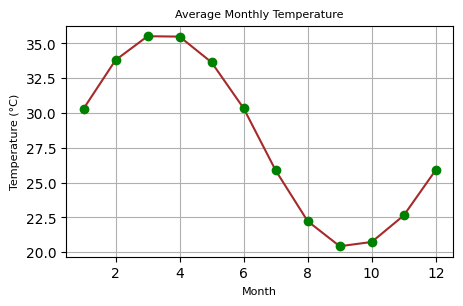

In [22]:
# Import Matplotlib library for plotting graphs
import matplotlib.pyplot as plt        # Used to create charts and visualizations, gave it the alias plt to write shorter code.

    #Line Plot: Show average temperature trends over time (monthly).
monthly_temp = df.groupby("month")["Temperature"].mean()  # Monthly average temperature

plt.figure(figsize=(5,3))          # create a figure with a size of 8 × 5 inches
plt.plot(monthly_temp.index,
         monthly_temp.values, color='brown', marker="o", markerfacecolor="green", markeredgecolor="green")
         # Create line plot, The X-axis represents the months, the Y-axis is average temperature.

plt.title("Average Monthly Temperature", fontsize=8)   # Add title
plt.xlabel("Month", fontsize=8)                        # Label x-axis
plt.ylabel("Temperature (°C)", fontsize=8)            # Label y-axis
plt.grid(True)                             # Show grid to ease readability
plt.show()                                 # Display plot

#Business Insights:
Temperature Trend:

* Average temperatures increase during summer months and decrease during winter months.
* Businesses can use this information to prepare for seasonal demand.
* Example: Ice cream and cold beverage sales may increase during hotter months.



In [23]:
df["Year"] = df["Date"].dt.year      # Extract year from the Date column and create a new 'month' column

print(df[["Date", "Year"]].head(50))    # Display Date and Month columns to verify the extraction

         Date  Year
0  2015-01-01  2015
1  2015-01-02  2015
2  2015-01-03  2015
3  2015-01-04  2015
4  2015-01-05  2015
5  2015-01-06  2015
6  2015-01-07  2015
7  2015-01-08  2015
8  2015-01-09  2015
9  2015-01-10  2015
10 2015-01-11  2015
11 2015-01-12  2015
12 2015-01-13  2015
13 2015-01-14  2015
14 2015-01-15  2015
15 2015-01-16  2015
16 2015-01-17  2015
17 2015-01-18  2015
18 2015-01-19  2015
19 2015-01-20  2015
20 2015-01-21  2015
21 2015-01-22  2015
22 2015-01-23  2015
23 2015-01-24  2015
24 2015-01-25  2015
25 2015-01-26  2015
26 2015-01-27  2015
27 2015-01-28  2015
28 2015-01-29  2015
29 2015-01-30  2015
30 2015-01-31  2015
31 2015-02-01  2015
32 2015-02-02  2015
33 2015-02-03  2015
34 2015-02-04  2015
35 2015-02-05  2015
36 2015-02-06  2015
37 2015-02-07  2015
38 2015-02-08  2015
39 2015-02-09  2015
40 2015-02-10  2015
41 2015-02-11  2015
42 2015-02-12  2015
43 2015-02-13  2015
44 2015-02-14  2015
45 2015-02-15  2015
46 2015-02-16  2015
47 2015-02-17  2015
48 2015-02-18  2015


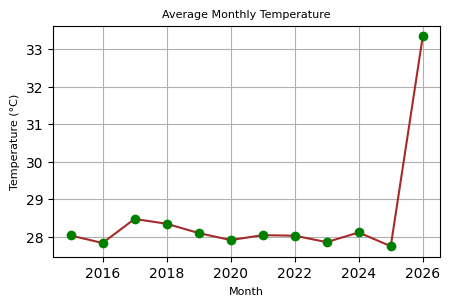

In [24]:
 #Line Plot: Show average temperature trends over time (yearly).
monthly_temp = df.groupby("Year")["Temperature"].mean()  # yearly average temperature

plt.figure(figsize=(5,3))           # create a figure with a size of 8 × 5 inches
plt.plot(monthly_temp.index,
         monthly_temp.values, color='brown', marker="o", markerfacecolor="green", markeredgecolor="green")
# Create line plot, The X-axis represents the months, the Y-axis is average temperature.

plt.title("Average Monthly Temperature", fontsize=8)   # Add title
plt.xlabel("Month", fontsize=8)                        # Label x-axis
plt.ylabel("Temperature (°C)", fontsize=8)            # Label y-axis
plt.grid(True)                             # Show grid
plt.show()                                 # Display plot

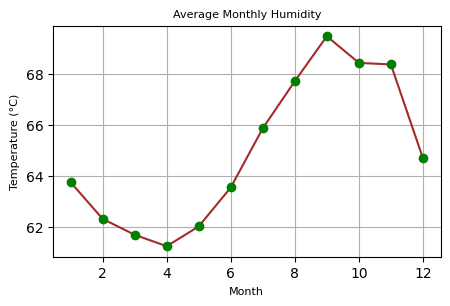

In [25]:
#Line Plot: Show average Humidity trends over time (monthly).
monthly_temp = df.groupby("month")["Humidity"].mean()  # Monthly average temperature

plt.figure(figsize=(5,3))          # create a figure with a size of 8 × 5 inches
plt.plot(monthly_temp.index,
         monthly_temp.values, color='brown', marker="o", markerfacecolor="green",
         markeredgecolor="green")               # Create line plot, The X-axis represents the months, the Y-axis is average temperature.

plt.title("Average Monthly Humidity", fontsize=8)   # Add title
plt.xlabel("Month", fontsize=8)                        # Label x-axis
plt.ylabel("Temperature (°C)", fontsize=8)            # Label y-axis
plt.grid(True)                             # enabled grid
plt.show()                                 # Display plot

#Business Insights:
Humidity Analysis:
* Humidity levels are high in 9th  and 10th Months i.e, September and October.
* High humidity levels may affect customer comfort and outdoor activities.
* Businesses such as tourism, construction, and event management can adjust their operations based on humidity trends.

**Bar Plot – Average Monthly Precipitation**

Next, I grouped the dataset by month using groupby() and calculated the average precipitation for each month using mean().

Then, I created a figure with a size of 8 × 5 inches to make the graph clear and readable.

After that, I used the bar() function to create a bar chart. The X-axis represents the months, and the Y-axis represents the average precipitation in millimeters (mm).

Next, I added a title using title() and labeled both axes using xlabel() and ylabel() so that the chart is easy to understand.

Finally, I displayed the bar chart using the show() function.

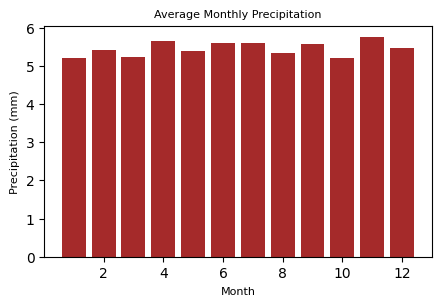

In [26]:
#Bar Plot: Compare average precipitation by month.
monthly_precip = df.groupby("month")["Precipitation"].mean()  # Monthly average precipitation

plt.figure(figsize=(5,3))
plt.bar(monthly_precip.index,
        monthly_precip.values, color='brown')             # Create bar plot

plt.title("Average Monthly Precipitation", fontsize=8) # Add title
plt.xlabel("Month", fontsize=8)                        # Label x-axis
plt.ylabel("Precipitation (mm)", fontsize=8)          # Label y-axis
plt.show()                                 # Display chart

# Business Insights:
Rainfall (Precipitation) Pattern:

* Months with higher precipitation indicate the rainy season. In this case, its November
* Retailers can increase inventory of umbrellas, raincoats, and waterproof products before these months.

First, I created a figure of size 8 × 5 inches using figure() to make the graph clear and readable.

Next, I used the hist() function to create a histogram of the Temperature column. A histogram shows how the temperature values are distributed in the dataset.

I set bins=20, which divides the temperature range into 20 equal intervals. Each bar represents the number of temperature values (frequency) that fall within a particular interval.

Then, I added a title using title() and labeled the X-axis as Temperature (°C) and the Y-axis as Frequency using xlabel() and ylabel().

Finally, I displayed the histogram using the show() function.

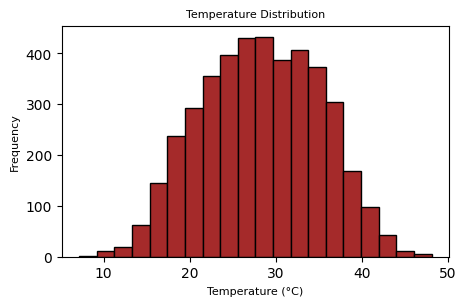

In [27]:
#Histogram: Show temperature distribution.
plt.figure(figsize=(5,3))
plt.hist(df["Temperature"],  bins=20,
         edgecolor="black", color='brown')                         # Create histogram

plt.title("Temperature Distribution", fontsize=8)      # Add title
plt.xlabel("Temperature (°C)", fontsize=8)            # Label x-axis
plt.ylabel("Frequency", fontsize=8)                   # Label y-axis
plt.show()                                 # Display histogram

The histogram shows how the temperature values are distributed. In my dataset, most temperatures are concentrated around 28°C, with fewer values at the lower and higher ends. This helps me understand the overall distribution and identify any unusual values.

Step 1: Calculate the Extreme Temperature Threshold

First, I calculated the threshold for identifying extreme temperatures. I used the mean() function to calculate the average temperature and the std() function to calculate the standard deviation. Then, I applied the formula Mean + 2 × Standard Deviation. Any temperature above this threshold is considered an extreme temperature.

Step 2: Filter Extreme Temperature Days

Next, I filtered the dataset to find all records where the temperature is greater than the calculated threshold. This returns only the days with unusually high temperatures.

Step 3: Display the Result
Finally, I displayed the filtered records to identify all the extreme temperature days descendingly accordance to celsius.

The mean represents the average value, and the standard deviation measures how much the data varies from the average. By adding two standard deviations to the mean, we set a threshold that identifies values that are significantly higher than normal. These values are treated as extreme temperatures.


In [28]:
#6. Identify Extreme Weather
    #Use NumPy to filter days with extreme temperature or precipitation values.

# Extreme Temperature Days
temp_threshold = np.mean(df["Temperature"]) + 2 * np.std(df["Temperature"])   # Calculate threshold
print(f"Extreme temp_threshold: {temp_threshold:.2f} mm")

extreme_temp = df[df["Temperature"] > temp_threshold]  # Filter extreme temperature days

extreme_temp = extreme_temp.sort_values(by="Temperature", ascending=False)   # Sort by temperature (highest first)
print(extreme_temp)

Extreme temp_threshold: 42.02 mm
           Date  Temperature   Humidity  Precipitation  month   season  Year
3716 2025-03-05        48.11  67.880000           8.62      3   Summer  2025
2305 2021-04-24        47.84  30.850000           3.60      4   Summer  2021
478  2016-04-23        47.71  56.480000           0.44      4   Summer  2016
1957 2020-05-11        46.67  80.000000          12.53      5   Summer  2020
1934 2020-04-18        46.21  69.970000           9.35      4   Summer  2020
113  2015-04-24        45.25  47.260000           7.31      4   Summer  2015
1165 2018-03-11        45.23  55.150000           1.59      3   Summer  2018
822  2017-04-02        45.20  49.850000          15.23      4   Summer  2017
847  2017-04-27        45.05  51.440000           6.16      4   Summer  2017
2989 2023-03-09        45.01  67.120000           6.14      3   Summer  2023
1911 2020-03-26        44.89  74.410000           7.82      3   Summer  2020
3380 2024-04-03        44.65  62.020000    

In [29]:
#Use NumPy to filter days with extreme precipitation values.

# Extreme Temperature Days
precip_threshold = np.mean(df["Precipitation"]) + 2 * np.std(df["Precipitation"])   # Calculate threshold
print(f"Extreme precip_threshold: {precip_threshold:.2f} mm")

extreme_precip = df[df["Precipitation"] > precip_threshold]  # Filter extreme temperature days

extreme_precip = extreme_precip.sort_values(by="Precipitation", ascending=False)   # Sort by temperature (highest first)
print(extreme_precip)

Extreme precip_threshold: 13.32 mm
           Date  Temperature   Humidity  Precipitation  month        season  \
1726 2019-09-23        17.93  60.890000          27.27      9  Post-Monsoon   
2710 2022-06-03        28.51  66.440000          24.70      6       Monsoon   
314  2015-11-11        27.14  61.480000          24.44     11  Post-Monsoon   
3384 2024-04-07        40.37  62.260000          23.90      4        Summer   
2153 2020-11-23        24.14  74.000000          23.70     11  Post-Monsoon   
...         ...          ...        ...            ...    ...           ...   
1261 2018-06-15        30.56  64.847313          13.41      6       Monsoon   
3475 2024-07-07        21.99  59.670000          13.41      7       Monsoon   
3774 2025-05-02        27.83  75.880000          13.39      5        Summer   
308  2015-11-05        23.60  60.700000          13.37     11  Post-Monsoon   
501  2016-05-16        41.29  67.510000          13.34      5        Summer   

      Year  
172

#Conclusion

This project analyzed weather data using NumPy, Pandas, and Matplotlib to understand patterns in temperature, humidity, and precipitation. After cleaning the dataset and handling missing values, statistical analysis and visualizations were performed to identify trends and relationships.

The analysis showed that the **average temperature was 28.26°C** with a **standard deviation of 6.88°C**, indicating moderate variation in temperature. The **average humidity was 64.85%** with a **standard deviation of 10.53%**, suggesting generally humid conditions throughout the dataset. The **average precipitation was 5.45 mm** with a **standard deviation of 3.93 mm**, indicating varying rainfall levels across different periods.

The median values—**28.26°C** for temperature, **64.78%** for humidity, and **4.51 mm** for precipitation—were close to their respective mean values, suggesting that the data distribution is fairly balanced with limited skewness.

Overall, the project demonstrates how Python libraries such as NumPy, Pandas, and Matplotlib can be used to clean, analyze, and visualize weather data. The insights gained from this analysis can support better planning and decision-making in sectors such as agriculture, tourism, transportation, and energy management.


In [32]:
df.columns

Index(['Date', 'Temperature', 'Humidity', 'Precipitation', 'month', 'season',
       'Year'],
      dtype='object')

In [36]:
#temp into array(numpy)
temp_array = df["Temperature"].to_numpy()
print(temp_array)

[30.12 27.72 31.   ... 28.48 27.   27.92]


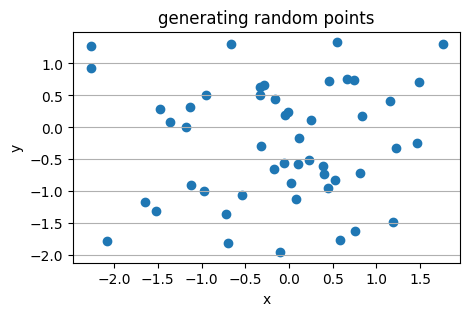

In [37]:
import matplotlib.pyplot as plt


x = np.random.randn(50)

y = np.random.randn(50)

plt.figure(figsize=(5,3))
plt.scatter(x,y,marker="o")
plt.title("generating random points")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(axis="y")
plt.show()